In [1]:
import pandas as pd #For reading csv files.
import numpy as np
import matplotlib.pyplot as plt #For plotting.

import PIL.Image as Image #For working with image files.

#Importing torch
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset,DataLoader #For working with data.

from torchvision import models,transforms #For pretrained models,image transformations.

In [2]:
import sys
print(sys.executable)


/home/akash/Downloads/dr_env/bin/python


In [3]:
import os
import zipfile

zip_path = "aptos2019-blindness-detection.zip"
extract_dir = "DR_images"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("Dataset Extracted Successfully!")


Dataset Extracted Successfully!


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #Use GPU if it's available or else use CPU.
print(device) #Prints the device we're using.

cuda


In [5]:
import os
os.listdir("/home/akash/Downloads/DR_images")


['sample_submission.csv',
 'test.csv',
 'train.csv',
 'test_images',
 'train_images']

In [6]:
import pandas as pd

path = "/home/akash/Downloads/DR_images"

train_df = pd.read_csv(f"{path}/train.csv")
print(f"No.of.training_samples: {len(train_df)}")

test_df = pd.read_csv(f"{path}/test.csv")
print(f"No.of.testing_samples: {len(test_df)}")


No.of.training_samples: 3662
No.of.testing_samples: 1928


In [7]:
pip install torch torchvision torchaudio


Note: you may need to restart the kernel to use updated packages.


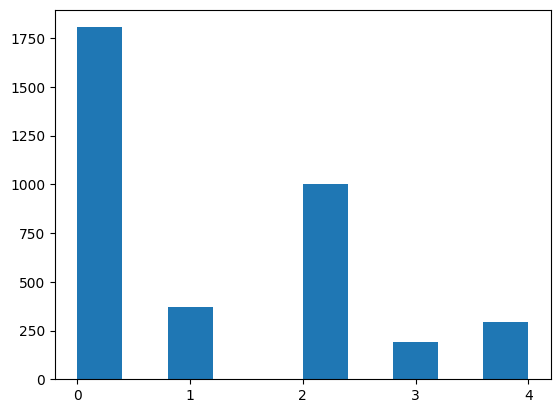

In [8]:
#Histogram of label counts.
train_df.diagnosis.hist()
plt.xticks([0,1,2,3,4])
plt.grid(False)
plt.show()

In [9]:

#As you can see,the data is imbalanced.
#So we've to calculate weights for each class,which can be used in calculating loss.

from sklearn.utils import class_weight #For calculating weights for each class.
class_weights = class_weight.compute_class_weight(class_weight='balanced',classes=np.array([0,1,2,3,4]),y=train_df['diagnosis'].values)
class_weights = torch.tensor(class_weights,dtype=torch.float).to(device)

print(class_weights) #Prints the calculated weights for the classes.

tensor([0.4058, 1.9795, 0.7331, 3.7948, 2.4827], device='cuda:0')


/tmp/ipykernel_365825/3295986.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  num = int(np.random.randint(0,len(train_df)-1,(1,))) #Picks a random number.


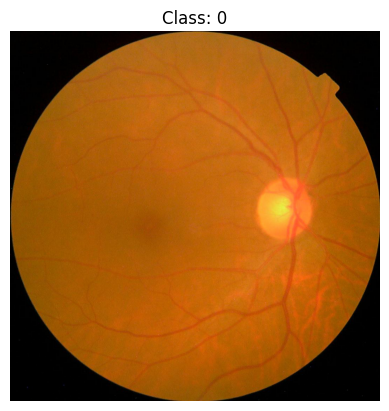

In [10]:

#For getting a random image from our training set.
num = int(np.random.randint(0,len(train_df)-1,(1,))) #Picks a random number.
sample_image = (f'{path}/train_images/{train_df["id_code"][num]}.png')#Image file.
sample_image = Image.open(sample_image)
plt.imshow(sample_image)
plt.axis('off')
plt.title(f'Class: {train_df["diagnosis"][num]}') #Class of the random image.
plt.show()


In [11]:
class dataset(Dataset): # Inherits from the Dataset class.
    '''
    dataset class overloads the __init__, __len__, __getitem__ methods of the Dataset class.

    Attributes :
        df:  DataFrame object for the csv file.
        data_path: Location of the dataset.
        image_transform: Transformations to apply to the image.
        train: A boolean indicating whether it is a training_set or not.
    '''

    def __init__(self,df,data_path,image_transform=None,train=True): # Constructor.
        super(Dataset,self).__init__() #Calls the constructor of the Dataset class.
        self.df = df
        self.data_path = data_path
        self.image_transform = image_transform
        self.train = train

    def __len__(self):
        return len(self.df) #Returns the number of samples in the dataset.

    def __getitem__(self,index):
        image_id = self.df['id_code'][index]
        image = Image.open(f'{self.data_path}/{image_id}.png') #Image.
        if self.image_transform :
            image = self.image_transform(image) #Applies transformation to the image.

        if self.train :
            label = self.df['diagnosis'][index] #Label.
            return image,label #If train == True, return image & label.

        else:
            return image #If train != True, return image.

In [12]:
image_transform = transforms.Compose([
    transforms.Resize((512,512)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
       (0.485, 0.456, 0.406),
       (0.229, 0.224, 0.225)
    )
]) #Transformations to apply to the image.
data_set = dataset(train_df,f'{path}/train_images',image_transform=image_transform)

#Split the data_set so that valid_set contains 0.1 samples of the data_set.
train_set,valid_set = torch.utils.data.random_split(data_set,[3302,360])

In [13]:
train_dataloader = DataLoader(train_set,batch_size=32,shuffle=True) #DataLoader for train_set.
valid_dataloader = DataLoader(valid_set,batch_size=32,shuffle=False) #DataLoader for validation_set.

In [14]:
#Since we've less data, we'll use Transfer learning.
model = models.resnet34(pretrained=True) #Downloads the resnet18 model which is pretrained on Imagenet dataset.

#Replace the Final layer of pretrained resnet18 with 4 new layers.
model.fc = nn.Sequential(nn.Linear(512,256),nn.Linear(256,128),nn.Linear(128,64),nn.Linear(64,5))

/home/akash/Downloads/dr_env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/akash/Downloads/dr_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [15]:
models.resnet34(pretrained=True)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [16]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [17]:
def train(dataloader, model, loss_fn, optimizer):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in dataloader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(x)
        loss = loss_fn(outputs, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc



In [18]:
def validate(dataloader, model, loss_fn):

    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in dataloader:

            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            loss = loss_fn(outputs, y)

            running_loss += loss.item() * y.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc


In [19]:
def optimize(train_dataloader, valid_dataloader, model, loss_fn, optimizer,
             nb_epochs, checkpoint_path=None):

    train_losses = []
    valid_losses = []
    start_epoch = 0

    # -------------------------
    # LOAD CHECKPOINT IF EXISTS
    # -------------------------
    if checkpoint_path is not None and os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)

        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        train_losses = checkpoint.get("train_losses", [])
        valid_losses = checkpoint.get("valid_losses", [])
        start_epoch = checkpoint.get("epoch", 0) + 1

        print(f"Resuming from epoch {start_epoch}")

    else:
        print("No checkpoint found — starting fresh.")

    # -------------------------
    # TRAIN LOOP
    # -------------------------
    for epoch in range(start_epoch, nb_epochs):

        print(f"\nEpoch [{epoch+1}/{nb_epochs}]")

        train_loss, train_acc = train(train_dataloader, model, loss_fn, optimizer)
        val_loss, val_acc = validate(valid_dataloader, model, loss_fn)

        train_losses.append(train_loss)
        valid_losses.append(val_loss)

        # ⭐⭐⭐ IMPORTANT ⭐⭐⭐
        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val   Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print(f"Current LR = {optimizer.param_groups[0]['lr']:.6f}")

        # SAVE CHECKPOINT
        if checkpoint_path is not None:
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_losses": train_losses,
                "valid_losses": valid_losses
            }, checkpoint_path)

        print(f"Checkpoint saved at epoch {epoch+1}")

    return train_losses, valid_losses


In [20]:
import os
os.makedirs("checkpoints", exist_ok=True)


In [21]:
checkpoint_path = "my_checkpoint.pth"


In [22]:
import os
if os.path.exists("my_checkpoint.pth"):
    os.remove("my_checkpoint.pth")
    print("Old checkpoint deleted")


Old checkpoint deleted


In [23]:
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
 #CrossEntropyLoss with class_weights.
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

nb_epochs = 25
checkpoint_path = 'my_checkpoint.pth'
#Call the optimize function.
train_losses, valid_losses = optimize(train_dataloader,valid_dataloader,model,loss_fn,optimizer,nb_epochs,checkpoint_path = checkpoint_path)


No checkpoint found — starting fresh.

Epoch [1/25]
Train Loss: 0.9120 | Train Acc: 74.62%
Val   Loss: 0.8790 | Val Acc: 77.78%
Current LR = 0.000100
Checkpoint saved at epoch 1

Epoch [2/25]
Train Loss: 0.7704 | Train Acc: 80.65%
Val   Loss: 0.8310 | Val Acc: 79.72%
Current LR = 0.000100
Checkpoint saved at epoch 2

Epoch [3/25]
Train Loss: 0.7424 | Train Acc: 82.65%
Val   Loss: 0.8335 | Val Acc: 76.39%
Current LR = 0.000100
Checkpoint saved at epoch 3

Epoch [4/25]
Train Loss: 0.7127 | Train Acc: 83.65%
Val   Loss: 0.7287 | Val Acc: 83.06%
Current LR = 0.000100
Checkpoint saved at epoch 4

Epoch [5/25]
Train Loss: 0.6948 | Train Acc: 85.25%
Val   Loss: 0.7418 | Val Acc: 82.78%
Current LR = 0.000100
Checkpoint saved at epoch 5

Epoch [6/25]
Train Loss: 0.6780 | Train Acc: 85.77%
Val   Loss: 0.8248 | Val Acc: 80.00%
Current LR = 0.000100
Checkpoint saved at epoch 6

Epoch [7/25]
Train Loss: 0.6549 | Train Acc: 86.83%
Val   Loss: 0.7267 | Val Acc: 83.89%
Current LR = 0.000100
Checkpoint

In [25]:
import torch
model.eval()

true_labels = []
pred_labels = []

with torch.no_grad():
    for x, y in valid_dataloader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        _, preds = torch.max(outputs, 1)

        true_labels.extend(y.cpu().numpy())
        pred_labels.extend(preds.cpu().numpy())


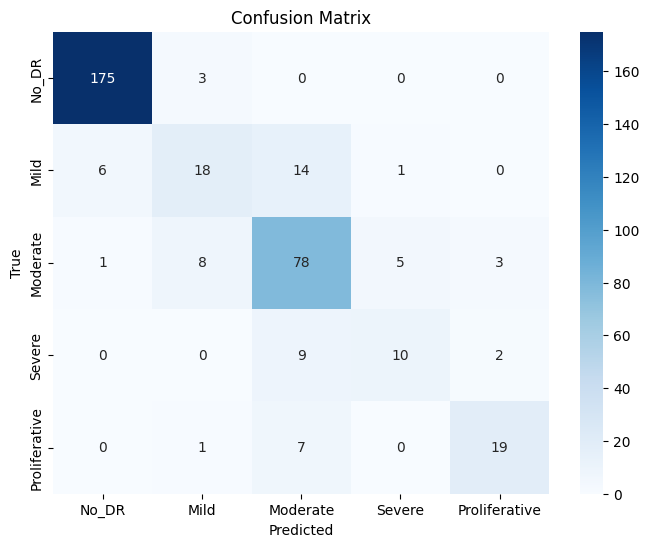

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, pred_labels)

class_names = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [27]:
valid_dataloader = DataLoader(valid_set, batch_size=32, shuffle=False)

true_labels = []
pred_labels = []

model.eval()
with torch.no_grad():
    for x, y in valid_dataloader:
        outputs = model(x.to(device))
        preds = outputs.argmax(dim=1).cpu().tolist()
        pred_labels.extend(preds)
        true_labels.extend(y.cpu().tolist())


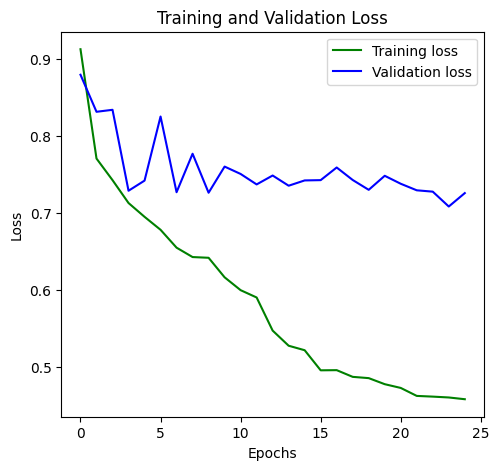

In [28]:
epochs = range(nb_epochs)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'g', label='Training loss')
plt.plot(epochs, valid_losses, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [29]:
from sklearn.metrics import classification_report

# Assuming true_labels and pred_labels are lists of ground truth and predicted class indices respectively

class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

report = classification_report(
    true_labels, pred_labels, target_names=class_names, digits=4, zero_division=0
)

print("Classification Report:\n")
print(report)


Classification Report:

               precision    recall  f1-score   support

        No DR     0.9778    0.9888    0.9832       178
         Mild     0.6944    0.6410    0.6667        39
     Moderate     0.7822    0.8316    0.8061        95
       Severe     0.5500    0.5238    0.5366        21
Proliferative     0.6957    0.5926    0.6400        27

     accuracy                         0.8528       360
    macro avg     0.7400    0.7156    0.7265       360
 weighted avg     0.8494    0.8528    0.8504       360



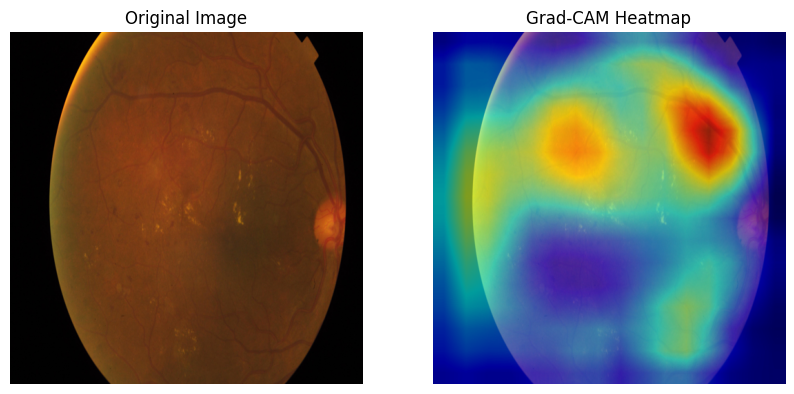

In [37]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

# Load your model and set to eval mode
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Choose last conv layer
target_layer = model.layer4[-1]
cam = GradCAM(model=model, target_layers=[target_layer])

# ---- LOAD ONE IMAGE ----
img_id = train_df.iloc[0]['id_code']   # pick first sample
img_path = f"{extract_dir}/train_images/{img_id}.png"

pil_img = Image.open(img_path).convert('RGB')

transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225)),
])

input_tensor = transform(pil_img).unsqueeze(0).to(device)

# numpy image for overlay
rgb_img = np.array(pil_img.resize((512,512))) / 255.0

# ---- GENERATE CAM ----
grayscale_cam = cam(input_tensor=input_tensor)[0]

cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# ---- SHOW ----
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title('Original Image')
plt.axis('off')
plt.imshow(rgb_img)

plt.subplot(1,2,2)
plt.title('Grad-CAM Heatmap')
plt.axis('off')
plt.imshow(cam_image)

plt.show()


In [38]:
test_set = dataset(test_df,f'{path}/test_images',image_transform = image_transform,train = False )

test_dataloader = DataLoader(test_set, batch_size=32, shuffle=False) #DataLoader for test_set.

In [39]:
def test(dataloader,model):
    '''
    test function predicts the labels given an image batches.

    Args :
         dataloader: DataLoader for the test_set.
         model: Given an input produces an output by multiplying the input with the model weights.

    Returns :
         List of predicted labels.
    '''

    model.eval() #Sets the model for evaluation.

    labels = [] #List to store the predicted labels.

    with torch.no_grad():

        for batch,x in enumerate(dataloader):

            output = model(x.to(device))

            predictions = output.argmax(dim=1).cpu().detach().tolist() #Predicted labels for an image batch.
            labels.extend(predictions)

    print('Testing has completed')

    return labels

In [40]:
labels = test(test_dataloader,model) #Calls the test function.

Testing has completed



Image 1 path: DR_images/train_images/3d3e288d490e.png


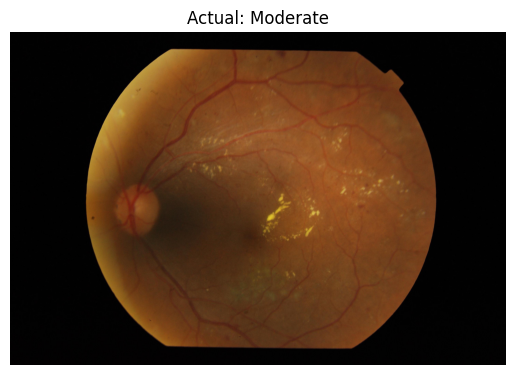

Predicted Label: Moderate

Image 2 path: DR_images/train_images/436e1793d240.png


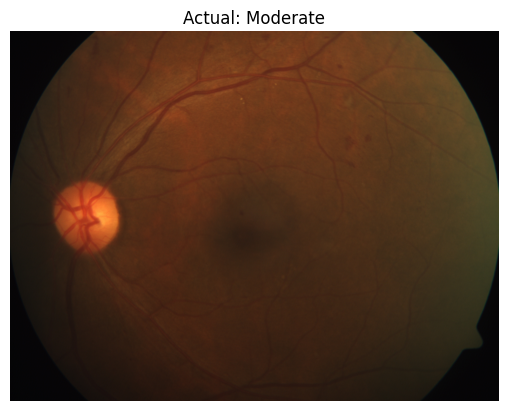

Predicted Label: Moderate


In [46]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms

# --- Validation transform (must match training normalization) ---
val_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])

# --- Class names ---
class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

# --- Ensure model in eval mode ---
model.eval()

# --- Pick 2 random rows from training set ---
random_samples = train_df.sample(2).reset_index(drop=True)

for i in range(2):

    img_id = random_samples["id_code"][i]
    label_true = random_samples["diagnosis"][i]

    # image path
    img_path = f"{extract_dir}/train_images/{img_id}.png"
    print(f"\nImage {i+1} path: {img_path}")

    # Load & show image
    img = Image.open(img_path).convert("RGB")
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Actual: {class_names[label_true]}")
    plt.show()

    # preprocess
    x = val_transform(img).unsqueeze(0).to(device)

    # predict
    with torch.no_grad():
        y = model(x)
        pred = y.argmax(1).item()

    print(f"Predicted Label: {class_names[pred]}")


In [47]:
import torch

checkpoint_path = 'my_checkpoint.pth'

# Load checkpoint (maps tensors to CPU if no GPU available)
checkpoint = torch.load(checkpoint_path, map_location='cpu')

# Print all keys in the checkpoint to view what’s stored
print("Checkpoint keys:", checkpoint.keys())

# Access common items:
epoch = checkpoint.get('epoch', None)
train_losses = checkpoint.get('train_losses', None)
valid_losses = checkpoint.get('valid_losses', None)
train_accuracies = checkpoint.get('train_accuracies', None)  # if saved
valid_accuracies = checkpoint.get('valid_accuracies', None)  # if saved

print(f"Epoch at checkpoint: {epoch}")
print(f"Train losses history: {train_losses}")
print(f"Validation losses history: {valid_losses}")
print(f"Train accuracies history: {train_accuracies}")
print(f"Validation accuracies history: {valid_accuracies}")

# You can also load model and optimizer states here:
# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])


Checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'train_losses', 'valid_losses'])
Epoch at checkpoint: 24
Train losses history: [0.912047762642623, 0.7703584564013743, 0.7423936028252365, 0.7127276723454173, 0.6948401735162533, 0.6780219705880302, 0.6548665471325348, 0.6426961116542389, 0.6417624920805175, 0.6164527287416788, 0.5997856421264138, 0.5903084670537028, 0.5474050646836219, 0.5277757801336639, 0.521956494835057, 0.4959145359455781, 0.49612929285258545, 0.48744062789637416, 0.48579670688298743, 0.47795544450099653, 0.4730866223230714, 0.46275323465114504, 0.4618314159486887, 0.4607250331965885, 0.45845876629608173]
Validation losses history: [0.8789648519621955, 0.8309622102313572, 0.8335311147901747, 0.728651950094435, 0.7417641758918763, 0.824822047021654, 0.7267351256476509, 0.7765871233410305, 0.726063174671597, 0.7599450217352973, 0.750400529967414, 0.7368349075317383, 0.7483700328403049, 0.7351579162809584, 0.7420123126771715, 0.742384203

In [50]:
import torch
torch.save(model.state_dict(), "resnet34.pth")
